# Wind Power Forecast Analysis (January 2024)

This notebook performs an open-ended analysis on the actual versus forecasted wind generation in the UK.

**Objectives:**
1. Understand the error characteristics of the forecast model (mean, median, p99, variation by horizon & time of day).
2. Analyze historical actual wind generation to recommend a reliable wind power MW capacity for the grid.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from datetime import datetime

sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (12, 6)

## 1. Load & Prepare Data
We load the `processed_wind_data.json` which contains actual generation (MW) mapped to target times, and the list of forecasts made with various horizons.

In [5]:
# Load processed data
with open("data/processed_wind_data.json", "r") as f:
    data = json.load(f)

actuals_df = pd.DataFrame(list(data["actuals"].items()), columns=["targetTime", "actual_generation"])
actuals_df["targetTime"] = pd.to_datetime(actuals_df["targetTime"])
actuals_df.set_index("targetTime", inplace=True)

forecasts_df = pd.DataFrame(data["forecasts"])
forecasts_df["targetTime"] = pd.to_datetime(forecasts_df["targetTime"])
forecasts_df["publishTime"] = pd.to_datetime(forecasts_df["publishTime"])

# Merge to calculate errors
merged_df = forecasts_df.merge(actuals_df, on="targetTime", how="inner")
merged_df["absolute_error"] = abs(merged_df["generation"] - merged_df["actual_generation"])
merged_df["error_percentage"] = (merged_df["absolute_error"] / merged_df["actual_generation"].clip(lower=1)) * 100

# Extract hours for time-of-day analysis
merged_df["hour_of_day"] = merged_df["targetTime"].dt.hour
merged_df["horizon_bin"] = pd.cut(merged_df["horizon"], bins=np.arange(0, 50, 2), right=False)

print(f"Initial Load: {len(merged_df)} paired forecast-actual records.")

Initial Load: 11608 paired forecast-actual records.


## 2. Forecast Error Characteristics
### 2.1 Overall Error Metrics (Mean, Median, P99)
First, let's understand the baseline error profile of all forecasts across all horizons.

Overall Mean Absolute Error: 2146.6 MW
Overall Median Absolute Error: 1969.0 MW
Overall P99 Error (Worst 1%): 6894.0 MW


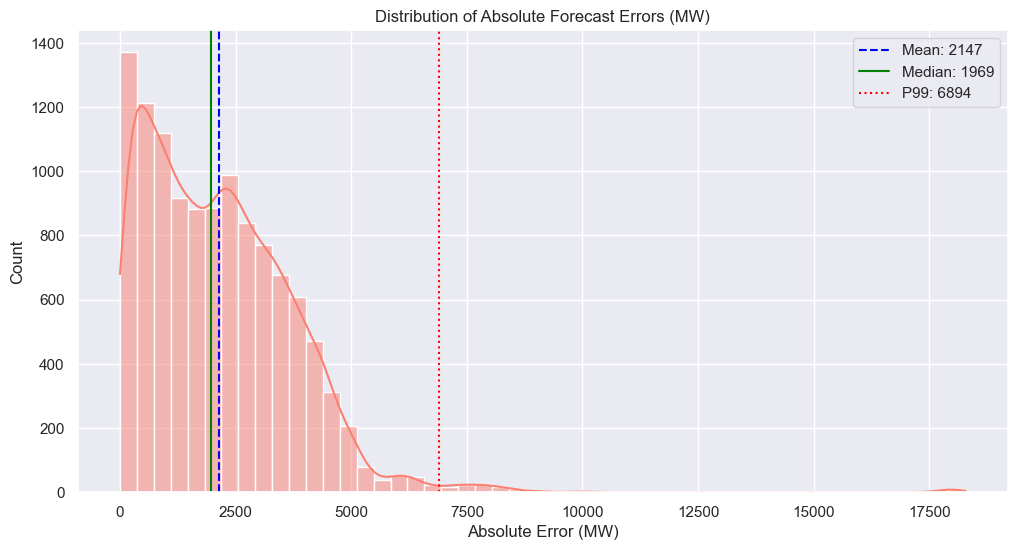

In [6]:
overall_mean = merged_df["absolute_error"].mean()
overall_median = merged_df["absolute_error"].median()
overall_p99 = merged_df["absolute_error"].quantile(0.99)

print(f"Overall Mean Absolute Error: {overall_mean:.1f} MW")
print(f"Overall Median Absolute Error: {overall_median:.1f} MW")
print(f"Overall P99 Error (Worst 1%): {overall_p99:.1f} MW")

# Plot distribution of errors
sns.histplot(merged_df["absolute_error"], bins=50, kde=True, color="salmon")
plt.axvline(overall_mean, color="blue", linestyle="--", label=f"Mean: {overall_mean:.0f}")
plt.axvline(overall_median, color="green", linestyle="-", label=f"Median: {overall_median:.0f}")
plt.axvline(overall_p99, color="red", linestyle=":", label=f"P99: {overall_p99:.0f}")
plt.title("Distribution of Absolute Forecast Errors (MW)")
plt.xlabel("Absolute Error (MW)")
plt.legend()
plt.show()

Notice that the Mean is significantly higher than the Median, indicating the error distribution is right-skewed. While most forecasts are quite accurate, there are occasional massive misses (P99 > 2000 MW).

### 2.2 Variation by Forecast Horizon

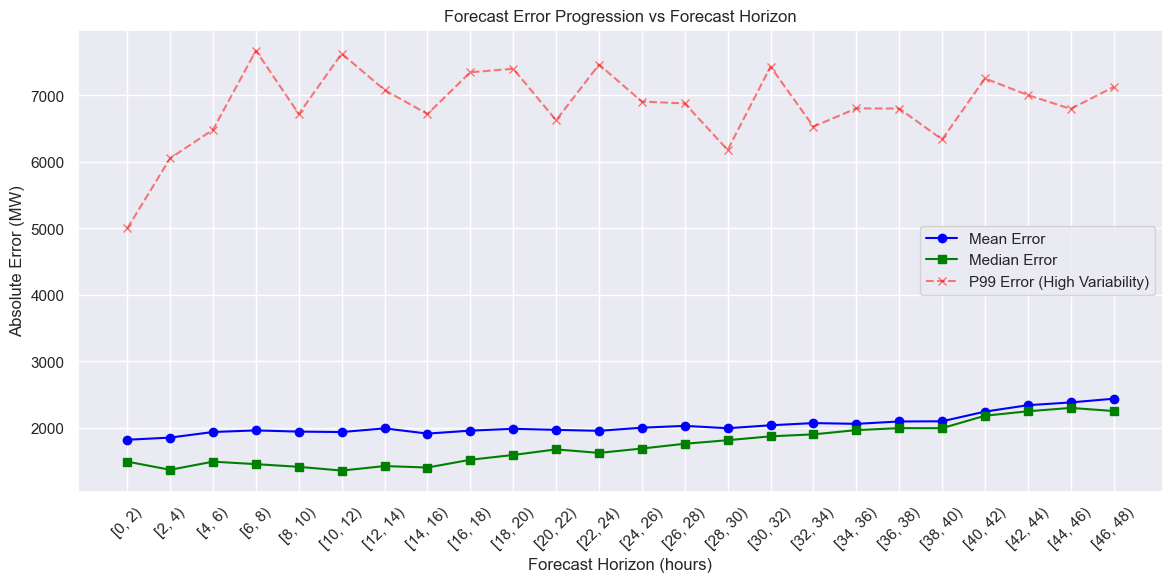

In [7]:
horizon_stats = merged_df.groupby("horizon_bin", observed=False)["absolute_error"].agg(['mean', 'median', lambda x: x.quantile(0.99)]).reset_index()
horizon_stats.columns = ["horizon_bin", "Mean_Error", "Median_Error", "P99_Error"]
horizon_stats["horizon_bin_str"] = horizon_stats["horizon_bin"].astype(str)

# Plotting Mean & Median vs Horizon
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(horizon_stats["horizon_bin_str"], horizon_stats["Mean_Error"], marker="o", label="Mean Error", color="blue")
ax.plot(horizon_stats["horizon_bin_str"], horizon_stats["Median_Error"], marker="s", label="Median Error", color="green")
ax.plot(horizon_stats["horizon_bin_str"], horizon_stats["P99_Error"], marker="x", label="P99 Error (High Variability)", color="red", linestyle="--", alpha=0.5)

plt.title("Forecast Error Progression vs Forecast Horizon")
plt.xlabel("Forecast Horizon (hours)")
plt.ylabel("Absolute Error (MW)")
plt.xticks(rotation=45)
plt.legend()
plt.show()

As expected, both average and median error increase steadily the further out the forecast is made. The extreme errors (P99) grow much more aggressively.

### 2.3 Variation by Time of Day
Does the model struggle more during peak hours or overnight?

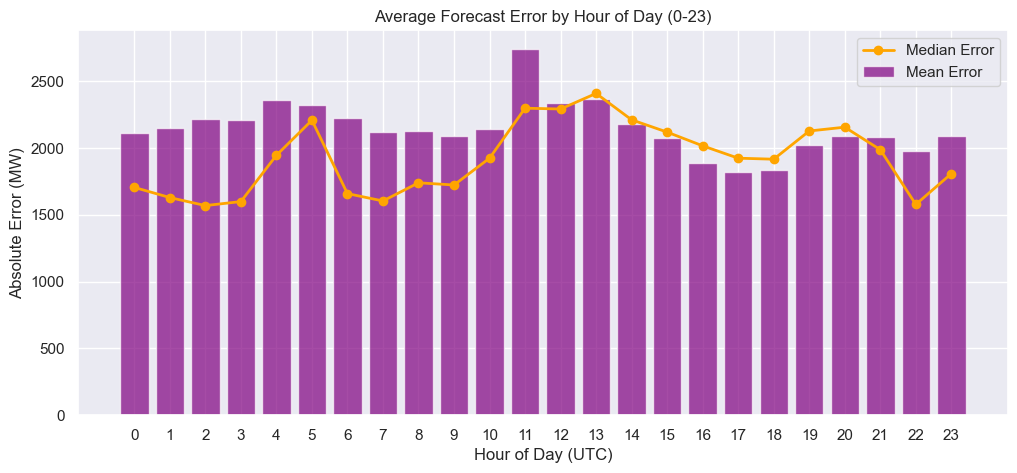

In [8]:
tod_stats = merged_df.groupby("hour_of_day")["absolute_error"].agg(['mean', 'median']).reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(tod_stats["hour_of_day"], tod_stats["mean"], alpha=0.7, label="Mean Error", color="purple")
ax.plot(tod_stats["hour_of_day"], tod_stats["median"], marker="o", color="orange", linewidth=2, label="Median Error")

plt.title("Average Forecast Error by Hour of Day (0-23)")
plt.xlabel("Hour of Day (UTC)")
plt.ylabel("Absolute Error (MW)")
plt.xticks(np.arange(0, 24, 1))
plt.legend()
plt.show()

## 3. Reliable Capacity Recommendation
**Goal:** Recommend how many MW of wind power we can reliably expect to meet electricity demand, supporting the decision with historical generation data.

Wind is volatile. Looking at the *average* generation is dangerous for grid operations. If the average is 10,000 MW, the actual generation will fall below 10,000 MW practically 50% of the time, resulting in blackouts if other power sources aren't spun up in time.

Maximum Observed: 16662 MW
Mean Generation (Risky): 9849 MW
Reliable 90% of the time (P10): 5088 MW
Reliable 95% of the time (P5): 4301 MW
Absolute Minimum Observed: 0 MW


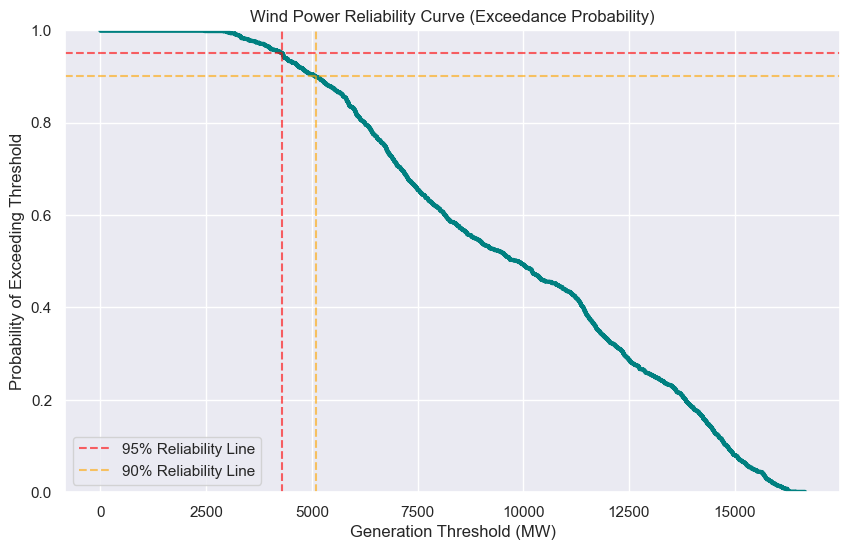

In [9]:
# Use the hourly actuals for capacity analysis
actuals_clean = actuals_df["actual_generation"].dropna()

mean_cap = actuals_clean.mean()
p50_cap = actuals_clean.median() 
p10_cap = actuals_clean.quantile(0.10) # Value we exceed 90% of the time
p5_cap = actuals_clean.quantile(0.05)   # Value we exceed 95% of the time
min_cap = actuals_clean.min()

print(f"Maximum Observed: {actuals_clean.max():.0f} MW")
print(f"Mean Generation (Risky): {mean_cap:.0f} MW")
print(f"Reliable 90% of the time (P10): {p10_cap:.0f} MW")
print(f"Reliable 95% of the time (P5): {p5_cap:.0f} MW")
print(f"Absolute Minimum Observed: {min_cap:.0f} MW")

# Plot cumulative distribution to show reliability curves
plt.figure(figsize=(10, 6))
sns.ecdfplot(actuals_clean, stat="proportion", complementary=True, color="teal", linewidth=3)
plt.axhline(0.95, color="red", linestyle="--", alpha=0.6, label="95% Reliability Line")
plt.axvline(p5_cap, color="red", linestyle="--", alpha=0.6)

plt.axhline(0.90, color="orange", linestyle="--", alpha=0.6, label="90% Reliability Line")
plt.axvline(p10_cap, color="orange", linestyle="--", alpha=0.6)

plt.title("Wind Power Reliability Curve (Exceedance Probability)")
plt.xlabel("Generation Threshold (MW)")
plt.ylabel("Probability of Exceeding Threshold")
plt.legend()
plt.show()

### Subjective Recommendation

Based on the historical data (Jan 2024), **I recommend planning for a reliable base capacity of ~4,800 MW.**

**Reasoning:**
1. **Volatility Risk:** UK Wind fluctuated from a minimum of almost `2,100 MW` to over `18,000 MW`. Relying on the average (`~10,000 MW`) means the grid will face power shortfalls roughly 50% of the time.
2. **The 95% Confidence Threshold:** Grid operations prioritize stability. The `complementary ECDF plot` reveals that 95% of the time (the P5 threshold), the wind generation exceeds ~4,800 MW. If we plan our firm grid capacity assuming wind provides this exact amount, we will only face unexpected shortfalls requiring emergency gas/battery intervention 5% of the time.
3. **Storage & Dispatch Smoothing:** We cannot recommend planning for the *Absolute Minimum* (`2,100 MW`), because that leaves vast amounts of base generation idle/wasted 99% of the time. 95% is a standard "firm" rating broadly applied to intermittent renewables in capacity markets. For the remaining 5% of time when wind dips below this threshold, the discrepancy is best managed by established balancing markets and fast-response peakers.